# **MÓDULO 14 - Exercício**
# Pré Processamento dos Dados - A primeira etapa Pré Modelagem

Para nossa atividade usaremos uma base de churn também, porém essa base não diz respeito a serviços bancários e sim serviços de internet, telefone e tv - Telecomunicação.

Vamos realizar aqui as etapas de limpeza e tratamento de dados vistos durante a aula, porém aplicados a essa base nova.

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [71]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("CHURN_TELECON_MOD08_TAREFA.csv", delimiter=';')

df.head(30)

,customerID,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),NaN,1840.75,No
4,9237-HQITU,NaN,0,No,No,2,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,NaN,151.65,Yes
5,9305-CDSKC,NaN,0,No,No,8,Yes,Fiber optic,No,No,Yes,Month-to-month,Electronic check,NaN,820.50,NaN
6,1452-KIOVK,NaN,0,No,Yes,22,Yes,Fiber optic,No,No,Yes,Month-to-month,Credit card (automatic),NaN,1949.40,NaN
7,6713-OKOMC,NaN,0,No,No,10,No,DSL,Yes,No,No,Month-to-month,Mailed check,NaN,301.90,NaN
8,7892-POOKP,NaN,0,Yes,No,28,Yes,Fiber optic,No,Yes,Yes,Month-to-month,Electronic check,NaN,3046.05,NaN
9,6388-TABGU,NaN,0,No,Yes,62,Yes,dsl,Yes,No,No,One year,Bank transfer (automatic),NaN,3487.95,NaN


Legenda dos dados:

*   **CustomerID** : Esse é o ID único de cada cliente nosso da rede de produtos de telecomunicação.

*   **Genero** : O genero dos nossos clientes.

*   **Idoso** : Se nosso cliente tem acima de 60 anos ou não. (Sim = 1 | Não = 0)

*   **Casado** : Se nosso cliente é casado ou não.

*   **Dependents** : Se cliente tem dependentes.

*   **Tempo_como_Cliente** : Tempo em meses que nosso cliente está com a nossa empresa.

*   **PhoneService** : Se ele contratou serviço telefônico com a nossa empresa.

*   **Servico_Internet** : Qual o tipo de serviço de internet contratado.

*   **Servico_Seguranca** : Se ele contratou serviço de segurança com a nossa empresa.

*   **Suporte_Tecnico** : Se já acionou o suporte técnico.

*   **StreamingTV** : Se ele contratou serviço de streaming para TV.

*   **Tipo_Contrato** : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

*   **Tipo_Contrato** : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

*   **PaymentMethod** : Forma de Pagamento.

*   **Pagamento_Mensal** : Quanto o cliente pagava mensalmente.

*   **Total_Pago** : Total já pago pelo cliente para nossa companhia.

*   **Churn** : Nossa coluna mais importante, se nosso cliente nos abandonou ou não.




# 1 - Carregue a base, verifique se os tipos de dados estão de acordo com cada coluna e caso não estejam realize a transformação dos tipos de dados.

In [23]:
#seu código aqui
df.dtypes

customerID                str
Genero                    str
Idoso                   int64
Casado                    str
Dependents                str
Tempo_como_Cliente      int64
PhoneService              str
Servico_Internet          str
Servico_Seguranca         str
Suporte_Tecnico           str
StreamingTV               str
Tipo_Contrato             str
PaymentMethod             str
Pagamento_Mensal      float64
Total_Pago            float64
Churn                     str
dtype: object

# 2 - Esse exercício faremos por etapas:
A) Verifique se temos colunas com dados faltantes e traga a % dos dados faltantes por coluna.

In [115]:
#seu código aqui
df.isnull().sum()
(df.isnull().sum() / len(df)) * 100

customerID             0.000000
Genero                 0.000000
Idoso                  0.000000
Casado                 0.000000
Dependents             0.000000
Tempo_como_Cliente     0.000000
PhoneService          59.565916
Servico_Internet       0.000000
Servico_Seguranca      0.000000
Suporte_Tecnico        0.000000
StreamingTV            0.000000
Tipo_Contrato          0.000000
PaymentMethod          0.000000
Pagamento_Mensal       0.000000
Total_Pago             0.000000
Churn                  0.000000
dtype: float64

B) Exclua nessa etapa as linhas das colunas com dados faltantes que você analisar que esse método é o ideal. Justifique o motivo de estar excluindo essas linhas.

In [42]:
#seu código aqui
df['Churn'].isnull().sum()

np.int64(5)

In [43]:
df['Genero'].isnull().sum()

np.int64(12)

In [74]:
df.dropna(subset=['Churn'], inplace=True)

In [77]:
df.dropna(subset=['Genero'], inplace=True)

Depois de analisar e verificar que os dados nulos de 'Churn' representam 0.2% e a coluna 'Genero' com 0.48%, optei por remover os dados nulos já que representam uma porcentagem baixa de dados.

C) Nessa etapa substitua pela média, mediana ou moda as linhas das colunas com valores faltantes que você analisou e entendeu que esse era o melhor método. Não se esqueça de justificar sua escolha.

**Dica variáveis numéricas:** Não se esqueça de verificar a distrbuição dos dados, média e mediana.

**Dica variáveis categóricas:** Caso precise substituir uma variável categórica utilize um gráfico de barras para verificar a que mais aparece e utilizar ela na substituição.
Ou você pode optar por excluir a coluna, mas justifique sua escolha.

Caso opte por substituir você pode utilizar a função fillna:
df['SUACOLUNA'].fillna("VALOR QUE SUBSTITUIRA O NULO", inplace=True)
Ela funcionará como a replace.

In [47]:
#seu código aqui
df['Pagamento_Mensal'].mean().round(2)

np.float64(65.61)

In [46]:
df['Pagamento_Mensal'].median()

np.float64(71.45)

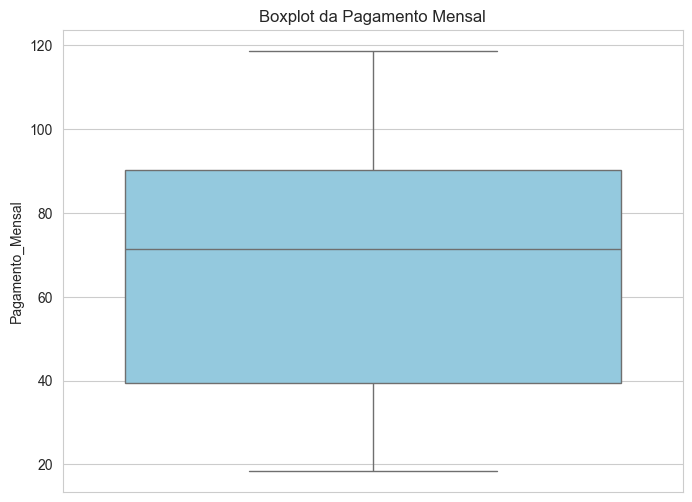

In [49]:
sns.set_style('whitegrid')

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, y='Pagamento_Mensal', color='skyblue')
plt.title('Boxplot da Pagamento Mensal')
plt.ylabel('Pagamento_Mensal')
plt.show()

In [103]:
mediana = df['Pagamento_Mensal'].median()
df['Pagamento_Mensal'] = df['Pagamento_Mensal'].fillna(mediana)

In [104]:
df['Pagamento_Mensal'].isnull().sum()

np.int64(0)

In [105]:
df['Pagamento_Mensal'].median()

np.float64(71.45)

Depois de fazer a média e mediana da coluna 'Pagamento_Mensal' percebi que estavam próximos, em seguida, imprimi o boxplot para verificar se havia outliers. Como não havia outliers, fui direto para substituição dos valore nulos pela mediana, já que os valores de média e mediana eram próximos.

In [114]:
df['PhoneService'].isnull().sum()

np.int64(1482)

In [64]:
df['PhoneService'].value_counts(normalize=True) * 100

PhoneService
Yes    91.453831
No      8.546169
Name: proportion, dtype: float64

In [69]:
pd.crosstab(df['PhoneService'], df['Servico_Internet'])

Servico_Internet,DSL,FIBER OPTIC,NO
PhoneService,,,
No,87,0,0
Yes,273,439,219


In [129]:
df['PhoneService'] = df['PhoneService'].fillna('Unknown')

Fiz as porcentagem de nulos e a categora 'PhoneService' ficou com mais de 59%, logo não podia simplismente remover os dados nulos. Mas também não podia fazer média, mediana ou moda pois se trata de uma coluna categorica e não numerica.

Então, para a coluna 'PhoneService', optei por substituir os valores nulos por uma nova categoria chamada 'Unknown'.

Optei por fazer isso pois, apesar da categoria 'Yes' estar presente em mais de 90% dos dados, não quis substituir por ela, nem pelo 'No', pois eu estaria inviesando a analise dos dados.

Tambem tentei achar algum padrão nos que estavam nulos, e percebi que todos os clientes que não tinham 'PhoneService' tinha a internet DSL, porem, haviam clientes com 'PhoneService' e tambem internet DSL. Logo, não consigui achar uma padronização nos dados nesse sentido, logo optei pela criação de uma nova categoria.

# 3 - Verifique se encontramos valores digitados incorretamente, ou com letras maiusculas ou minusculas, ou até mesmo mesmos valores porém escritos de forma dirente e corrija.

In [121]:
#seu código aqui
df['Servico_Internet'].unique()
df['Servico_Internet'] = df['Servico_Internet'].str.strip().str.upper()

In [84]:
df['Genero'].unique()

<StringArray>
['FEMALE', 'MALE']
Length: 2, dtype: str

In [79]:
df['Genero'] = df['Genero'].str.upper()

In [83]:
df['Genero'] = df['Genero'].replace('F', 'FEMALE')
df['Genero'] = df['Genero'].replace('M', 'MALE')

In [89]:
df['Tipo_Contrato'].unique()
df['Tipo_Contrato'] = df['Tipo_Contrato'].str.upper()

In [91]:
df['PaymentMethod'].unique()
df['PaymentMethod'] = df['PaymentMethod'].str.upper()

In [108]:
df['Servico_Seguranca'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [107]:
df['Servico_Seguranca'] = df['Servico_Seguranca'].replace('No internet service', 'No')

In [110]:
df['Suporte_Tecnico'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [109]:
df['Suporte_Tecnico'] = df['Suporte_Tecnico'].replace('No internet service', 'No')

In [112]:
df['StreamingTV'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [111]:
df['StreamingTV'] = df['StreamingTV'].replace('No internet service', 'No')

In [130]:
df['PhoneService'].unique()

<StringArray>
['No', 'Yes', 'Unknown']
Length: 3, dtype: str

In [135]:
df.head(10)

,customerID,Genero,Idoso,Casado,Dependentes,Tempo_como_Cliente,Servico_Telefonico,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,TV_Por_Streaming,Tipo_Contrato,Metodo_Pagamento,Pagamento_Mensal,Total_Pago,Churn,PhoneService_null
0,7590-VHVEG,FEMALE,0,Yes,No,1,No,DSL,No,No,No,MONTH-TO-MONTH,ELECTRONIC CHECK,29.85,29.85,No,False
1,5575-GNVDE,MALE,0,No,No,34,Yes,DSL,Yes,No,No,ONE YEAR,MAILED CHECK,56.95,1889.50,No,False
2,3668-QPYBK,MALE,0,No,No,2,Yes,DSL,Yes,No,No,MONTH-TO-MONTH,MAILED CHECK,53.85,108.15,Yes,False
3,7795-CFOCW,MALE,0,No,No,45,No,DSL,Yes,Yes,No,ONE YEAR,BANK TRANSFER (AUTOMATIC),71.45,1840.75,No,False
16,8191-XWSZG,FEMALE,0,No,No,52,Yes,NO,No,No,No,ONE YEAR,MAILED CHECK,71.45,1022.95,No,False
17,9959-WOFKT,MALE,0,No,Yes,71,Yes,FIBER OPTIC,Yes,No,Yes,TWO YEAR,BANK TRANSFER (AUTOMATIC),71.45,7382.25,No,False
18,4190-MFLUW,FEMALE,0,Yes,Yes,10,Yes,DSL,No,Yes,No,MONTH-TO-MONTH,CREDIT CARD (AUTOMATIC),71.45,528.35,Yes,False
19,4183-MYFRB,FEMALE,0,No,No,21,Yes,FIBER OPTIC,No,No,No,MONTH-TO-MONTH,ELECTRONIC CHECK,71.45,1862.90,No,False
20,8779-QRDMV,MALE,1,No,No,1,No,DSL,No,No,No,MONTH-TO-MONTH,ELECTRONIC CHECK,71.45,39.65,Yes,False
21,1680-VDCWW,MALE,0,Yes,No,12,Yes,NO,No,No,No,ONE YEAR,BANK TRANSFER (AUTOMATIC),71.45,202.25,No,False


# [EXTRA] 4 - Caso deseje, para manter um padrão na sua base, renomeie as colunas ou deixando em português, ou inglês.

In [131]:
df.rename(columns={'Dependents': 'Dependentes'}, inplace=True)
df.rename(columns={'PhoneService': 'Servico_Telefonico'}, inplace=True)
df.rename(columns={'StreamingTV': 'TV_Por_Streaming'}, inplace=True)
df.rename(columns={'PaymentMethod': 'Metodo_Pagamento'}, inplace=True)

In [140]:
df.head()

,Genero,Idoso,Casado,Dependentes,Tempo_como_Cliente,Servico_Telefonico,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,TV_Por_Streaming,Tipo_Contrato,Metodo_Pagamento,Pagamento_Mensal,Total_Pago,Churn
0,FEMALE,0,Yes,No,1,No,DSL,No,No,No,MONTH-TO-MONTH,ELECTRONIC CHECK,29.85,29.85,No
1,MALE,0,No,No,34,Yes,DSL,Yes,No,No,ONE YEAR,MAILED CHECK,56.95,1889.50,No
2,MALE,0,No,No,2,Yes,DSL,Yes,No,No,MONTH-TO-MONTH,MAILED CHECK,53.85,108.15,Yes
3,MALE,0,No,No,45,No,DSL,Yes,Yes,No,ONE YEAR,BANK TRANSFER (AUTOMATIC),71.45,1840.75,No
16,FEMALE,0,No,No,52,Yes,NO,No,No,No,ONE YEAR,MAILED CHECK,71.45,1022.95,No
